### Сколько Вы реально зарабатываете с одной продажи: юнит-экономика с учетом возвратов

#### Цель проекта
Оценить прибыльность каждой позиции ассортимента, найти точку безубыточности и определить риски, связанные с процентом выкупа.

#### Критический инсайт
Категория "Одежда" имеет маржинальность 3-6%, что значительно ниже рыночной нормы (25-35%). Требуется либо срочный пересмотр ценообразования и себестоимости, либо вывод товара из ассортимента.

#### Ключевые инсайты
1. **Раздел "Электроника" - это лидер бизнеса:** самая высокая маржинальность (18-21%) и высокий процент выкупа (85-90%) Требует наименьшего объема продаж для покрытия постоянных расходов.
2. **Раздел "Одежда" - это зона риска:** низкий процент выкупа (50-60%) приводит к потере 74-80% потенциальной прибыли. Одна позиция ("Футболка оверсайз") убыточна.
3. **Точка безубыточности:** при постоянных расходах в 250 тысяч рублей в месяц, нужно продавать 242-842 единицы товара из категории "Электроника", а "Одежде" - от 2042 до 5122.
4. **Устойчивость к рискам:** позиция "Умная колонка" остается прибыльной даже при падении выкупа до 30%.

### Рекомендации
1. **Главный приоритет** - поэтапное повышение цены для отдельных позиций (рекомендуется "Худи базовое", так как оно является самой стабильной позицией в категории): +1-2% к текущей цене, мониторинг общей прибыли и количества заказов 3-4 дня. Если показатели стабильны или прибыль растет, то повторяем. Повторяем до достижения маржинальности 20-25%. Если общие заказы падают на 30-40%, откатываемся на последнюю успешную цену. Если после 2-3 итерация не удается поднять маржинальность до 20-25%, рассматриваем вывод товаров этой категории. Для остальных позиций применять подобные тесты только при наличии свободных ресурсов.
2. **Второй приоритет** - протестировать гипотезы для увеличения процента выкупа в категории "Одежда" на 5% (например, улучшение качества фото и видео для максимального соответствия реальности). Тест проводить на одном отдельно взятом товаре. Ожидаемый эффект при улучшении процента выкупа на 5% для позциии "Худи базовое" - **+23.6% прибыли для этой позиции** даже при нынешней маржинальности. 15
3. В долгосрочной перспективе протестировать поиск альтернативных поставщиков на 1-2 позициях категории "Одежда". Снижение себестоимости на 10-15% способно увеличить маржинальность до 13-21%, что уже ближе к рыночной норме.
4. Для позиции "Футболка оверсайз" рассмотреть возможность срочных решений: повышение цены на 20-25% или снижение себестоимости на 10-15%. Если математика не сходится, то продать остатки и вывести из ассортимента. Не тратить ресурсы на улучшение фото/видео для данного товара.
4. Позиция "Органайзер для белья" имеет маржинальность ниже средней. Остальные позиции категории находятся на грани нормы. Рекомендуется протестировать действия, аналогичные категории "Одежда", подняв маржинальность до как минимум 25%.
5. Добавить 1 новую позицию в категорию "Электроника" и протестировать на малой партии. После стабилизации маржинальности других категорий проанализировать данные по оборачиваемости в разделе "Электроника" и на основе их принять решение о масштабировании для диверсификации рисков.

In [11]:
# ПРИМЕЧАНИЕ: В данном расчете учитывается базовая маржинальная прибыль, поэтому не учтены расходы на маркетинг. Чтобы получить чистую прибыль, нужно
# из expected_profit_per_unit вычесть CAC/расходы на рекламу.

import pandas as pd
import numpy as np

data = {
    'product_id': range(1, 11),
    'product_name': [
        'Беспроводные наушники TWS', 'Умная колонка', 'Портативная зарядка 20000mAh',
        'Ортопедическая подушка', 'Набор кухонных ножей', 'Органайзер для белья',
        'Футболка оверсайз (XL)', 'Джинсы классические', 'Худи базовое', 'Платье летнее'
    ],
    'category': ['Электроника'] * 3 + ['Товары для дома'] * 3 + ['Одежда'] * 4,
    'cost_price': [1200, 2500, 600, 850, 1100, 400, 350, 900, 800, 700],
    'selling_price': [2490, 4990, 1490, 2290, 2890, 990, 890, 2190, 1890, 1590],
    'commission_mpl': [0.15, 0.15, 0.15, 0.19, 0.19, 0.19, 0.25, 0.25, 0.25, 0.25],
    'logistics_cost': [200, 250, 180, 190, 220, 150, 120, 150, 150, 150],
    'reverse_logistics_cost': [100, 120, 90, 95, 110, 75, 60, 75, 75, 75],
    'buyout_rate': [0.88, 0.90, 0.85, 0.75, 0.78, 0.80, 0.55, 0.50, 0.60, 0.58],
    'tax_rate': [0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06]
}

# Для удобства расчетов колонки "комиссия маркетплейса", "процент выкупа" и "УСН" сразу переведены в числовые значения

df_products = pd.DataFrame(data)
df_products.to_csv('products.csv', index=False, encoding='utf-8-sig')

# Считаем прибыль, если клиент выкупил товар
df_products['profit_if_bought'] = df_products['selling_price'] - df_products['cost_price'] - (df_products['selling_price'] * df_products['tax_rate']) - \
(df_products['selling_price'] * df_products['commission_mpl']) - df_products['logistics_cost']

# Считаем убыток, если клиент совершил возврат
df_products['loss_if_returned'] = -(df_products['logistics_cost'] + df_products['reverse_logistics_cost'])

# Математическое ожидание прибыли с одной отгрузки
df_products['expected_profit_per_unit'] = (df_products['profit_if_bought'] * df_products['buyout_rate']) + \
(df_products['loss_if_returned'] * (1 - df_products['buyout_rate']))

# Математическое ожидание маржинальности (%)
df_products['expected_margin (%)'] = (df_products['expected_profit_per_unit'] / df_products['selling_price']) * 100

# Потеряно от потолка прибыли (%)
df_products['lost_profit_potential (%)'] = 100 - (df_products['expected_profit_per_unit'] / df_products['profit_if_bought']) * 100

# Задаем фиксированные расходы (в рублях)
fixed_costs = 250000

# Точка безубыточности (позиции с отрицательной маржинальной прибылью обозначаем как 0)
df_products['break_even_point'] = np.ceil((fixed_costs / df_products['expected_profit_per_unit']).clip(lower=0))

df_products = df_products.rename(columns={
    'product_id': 'ID товара',
    'product_name': 'Название товара',
    'category': 'Категория',
    'cost_price': 'Себестоимость',
    'selling_price': 'Цена продажи',
    'commission_mpl': 'Комиссия маркетплейса',
    'logistics_cost': 'Логистика',
    'reverse_logistics_cost': 'Обратная логистика',
    'buyout_rate': 'Процент выкупа',
    'tax_rate': 'Налог (УСН)',
    'profit_if_bought': 'Прибыль при выкупе',
    'loss_if_returned': 'Убыток при возврате',
    'expected_profit_per_unit': 'Ожидаемая прибыль с единицы',
    'expected_margin (%)': 'Ожидаемая маржинальность (%)',
    'lost_profit_potential (%)': 'Упущенный потенциал прибыли (%)',
    'break_even_point': 'Точка безубыточности (шт)'
})

from IPython.display import HTML
from IPython.display import Markdown, display

HTML("""
<style>
.dataframe {
    transform: scale(0.85);
    transform-origin: top left;
    margin-bottom: 20px;
}
</style>
""")

# Таблица 1: Вводные данные
display(Markdown('### Исходные данные по ассортименту'))
display(df_products[['Название товара', 'Категория', 'Себестоимость', 'Цена продажи', 
                      'Комиссия маркетплейса', 'Логистика', 'Обратная логистика', 
                      'Процент выкупа', 'Налог (УСН)']].style
        .format({'Комиссия маркетплейса': '{:.2f}', 'Процент выкупа': '{:.2f}', 'Налог (УСН)': '{:.2f}'})
        .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

# Таблица 2: Расчетные показатели
display(Markdown('### Оценка реального заработка от каждого товара'))
display(df_products[['Название товара', 'Прибыль при выкупе', 'Убыток при возврате', 
                      'Ожидаемая прибыль с единицы', 'Ожидаемая маржинальность (%)', 
                      'Упущенный потенциал прибыли (%)', 'Точка безубыточности (шт)']].style
        .format({'Ожидаемая маржинальность (%)': '{:.1f}%', 
                 'Упущенный потенциал прибыли (%)': '{:.1f}%',
                 'Прибыль при выкупе': '{:.0f}',
                 'Убыток при возврате': '{:.0f}',
                 'Ожидаемая прибыль с единицы': '{:.0f}',
                 'Точка безубыточности (шт)': '{:.0f}'})
        .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))


### Исходные данные по ассортименту

,Название товара,Категория,Себестоимость,Цена продажи,Комиссия маркетплейса,Логистика,Обратная логистика,Процент выкупа,Налог (УСН)
0,Беспроводные наушники TWS,Электроника,1200,2490,0.15,200,100,0.88,0.06
1,Умная колонка,Электроника,2500,4990,0.15,250,120,0.90,0.06
2,Портативная зарядка 20000mAh,Электроника,600,1490,0.15,180,90,0.85,0.06
3,Ортопедическая подушка,Товары для дома,850,2290,0.19,190,95,0.75,0.06
4,Набор кухонных ножей,Товары для дома,1100,2890,0.19,220,110,0.78,0.06
5,Органайзер для белья,Товары для дома,400,990,0.19,150,75,0.80,0.06
6,Футболка оверсайз (XL),Одежда,350,890,0.25,120,60,0.55,0.06
7,Джинсы классические,Одежда,900,2190,0.25,150,75,0.50,0.06
8,Худи базовое,Одежда,800,1890,0.25,150,75,0.60,0.06
9,Платье летнее,Одежда,700,1590,0.25,150,75,0.58,0.06


### Оценка реального заработка от каждого товара

,Название товара,Прибыль при выкупе,Убыток при возврате,Ожидаемая прибыль с единицы,Ожидаемая маржинальность (%),Упущенный потенциал прибыли (%),Точка безубыточности (шт)
0,Беспроводные наушники TWS,567,-300,463,18.6%,18.3%,540
1,Умная колонка,1192,-370,1036,20.8%,13.1%,242
2,Портативная зарядка 20000mAh,397,-270,297,19.9%,25.2%,842
3,Ортопедическая подушка,677,-285,437,19.1%,35.5%,573
4,Набор кухонных ножей,848,-330,588,20.4%,30.6%,425
5,Органайзер для белья,192,-225,109,11.0%,43.4%,2294
6,Футболка оверсайз (XL),144,-180,-2,-0.2%,101.2%,0
7,Джинсы классические,461,-225,118,5.4%,74.4%,2118
8,Худи базовое,354,-225,122,6.5%,65.4%,2042
9,Платье летнее,247,-225,49,3.1%,80.2%,5122


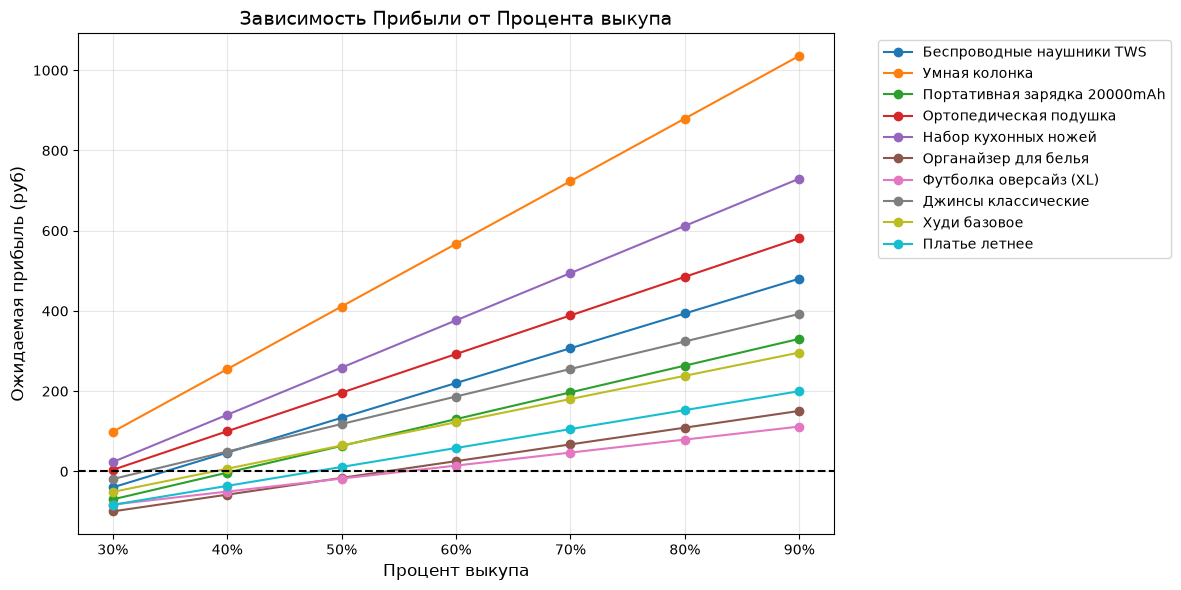

In [12]:
# Создадим графический анализ чувствительности на основе имеющихся данных

import matplotlib.pyplot as plt
import numpy as np

df_products = df_products.rename(columns={
    'Цена продажи': 'selling_price',
    'Себестоимость': 'cost_price',
    'Логистика': 'logistics_cost',
    'Обратная логистика': 'reverse_logistics_cost',
    'Комиссия маркетплейса': 'commission_mpl',
    'Налог (УСН)': 'tax_rate',
    'Процент выкупа': 'buyout_rate',
    'Название товара': 'product_name'
})

buyout_rates = np.linspace(0.3, 0.9, 7)
plt.figure(figsize=(12, 6))

for index, row in df_products.iterrows():
    profits = [
    b * (row['selling_price'] - row['cost_price'] - row['logistics_cost'] 
         - row['selling_price'] * row['commission_mpl'] 
         - row['selling_price'] * row['tax_rate'])
    + (1 - b) * (-row['logistics_cost'] - row['reverse_logistics_cost'])
    for b in buyout_rates
]
    plt.plot(buyout_rates, profits, marker='o', label=row['product_name'])


plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Зависимость Прибыли от Процента выкупа', fontsize=14)
plt.xlabel('Процент выкупа', fontsize=12)
plt.ylabel('Ожидаемая прибыль (руб)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xticks(buyout_rates, [f'{int(b*100)}%' for b in buyout_rates])
plt.show()